### Task 1 - Asset Selection & Data Download
Financial Assets for the portfolio:
- HDFC AMC (Large Cap)
- Macpower CNC (Small Cap)
- NIFTY 50 (Index)
- EUR/INR (FX Rate)
- Gold (Commodity)

In [51]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
plt.style.use("default")
import warnings
warnings.filterwarnings("ignore")

In [52]:
# Define tickers
tickers = {
    "HDFC AMC (Large Cap)": "HDFCAMC.NS",
    "Macpower CNC (Small Cap)": "MACPOWER.NS",
    "NIFTY 50 (Index)": "^NSEI",
    "EUR/INR (FX Rate)": "EURINR=X",
    "Gold (Commodity)": "GC=F"
}

# Define date range
start_date = "2019-06-16" # nana's birthday
end_date = "2024-06-26" # dada's birthday

# Download adjusted close prices (USD/INR pulled alongside, just to convert Gold to INR/10g)
raw = yf.download(list(tickers.values()) + ["USDINR=X"], start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
raw.columns = list(tickers.keys()) + ["USD/INR"]

# Gold quoted by yfinance is USD per troy ounce; convert to INR per 10 grams,
# which is how gold is actually quoted in India (1 troy oz = 31.1034768 g)
raw["Gold (Commodity)"] = raw["Gold (Commodity)"] * raw["USD/INR"] / 31.1034768 * 10

data = raw[list(tickers.keys())]
data

[*********************100%***********************]  6 of 6 completed


,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
Date,,,,,
2019-06-17,78.195999,1338.699951,845.549011,116.606445,261826.604210
2019-06-18,78.297997,1346.599976,791.904602,117.180389,263546.205686
2019-06-19,77.869003,1344.599976,789.168823,117.180389,262238.855477
2019-06-20,78.175003,1392.900024,797.201172,114.788948,265785.207973
2019-06-21,78.445999,1396.199951,819.547485,128.181000,263027.719278
...,...,...,...,...,...
2024-06-19,89.454002,NaN,1873.254761,1381.594604,630355.680779
2024-06-20,89.611000,2369.000000,1869.364380,1449.147339,632066.769372
2024-06-21,89.397003,2331.199951,1879.258301,1399.180298,631675.216549


### Task 2 - Data Cleaning and Preprocessing
- Using Forward Fill (ffill) for missing values
- Calculate log returns
- Visualization using Line Charts and Histograms 

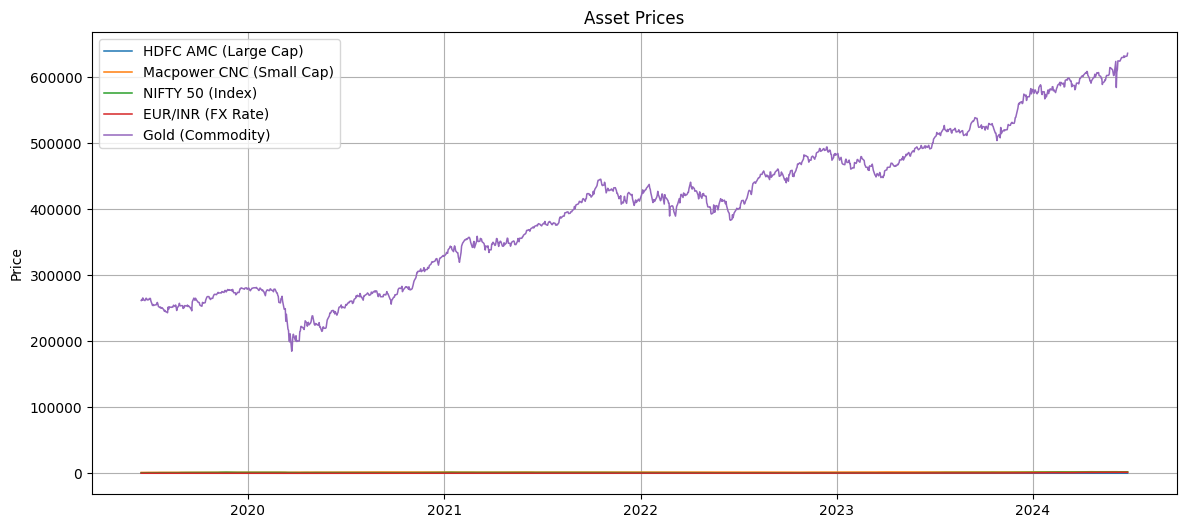

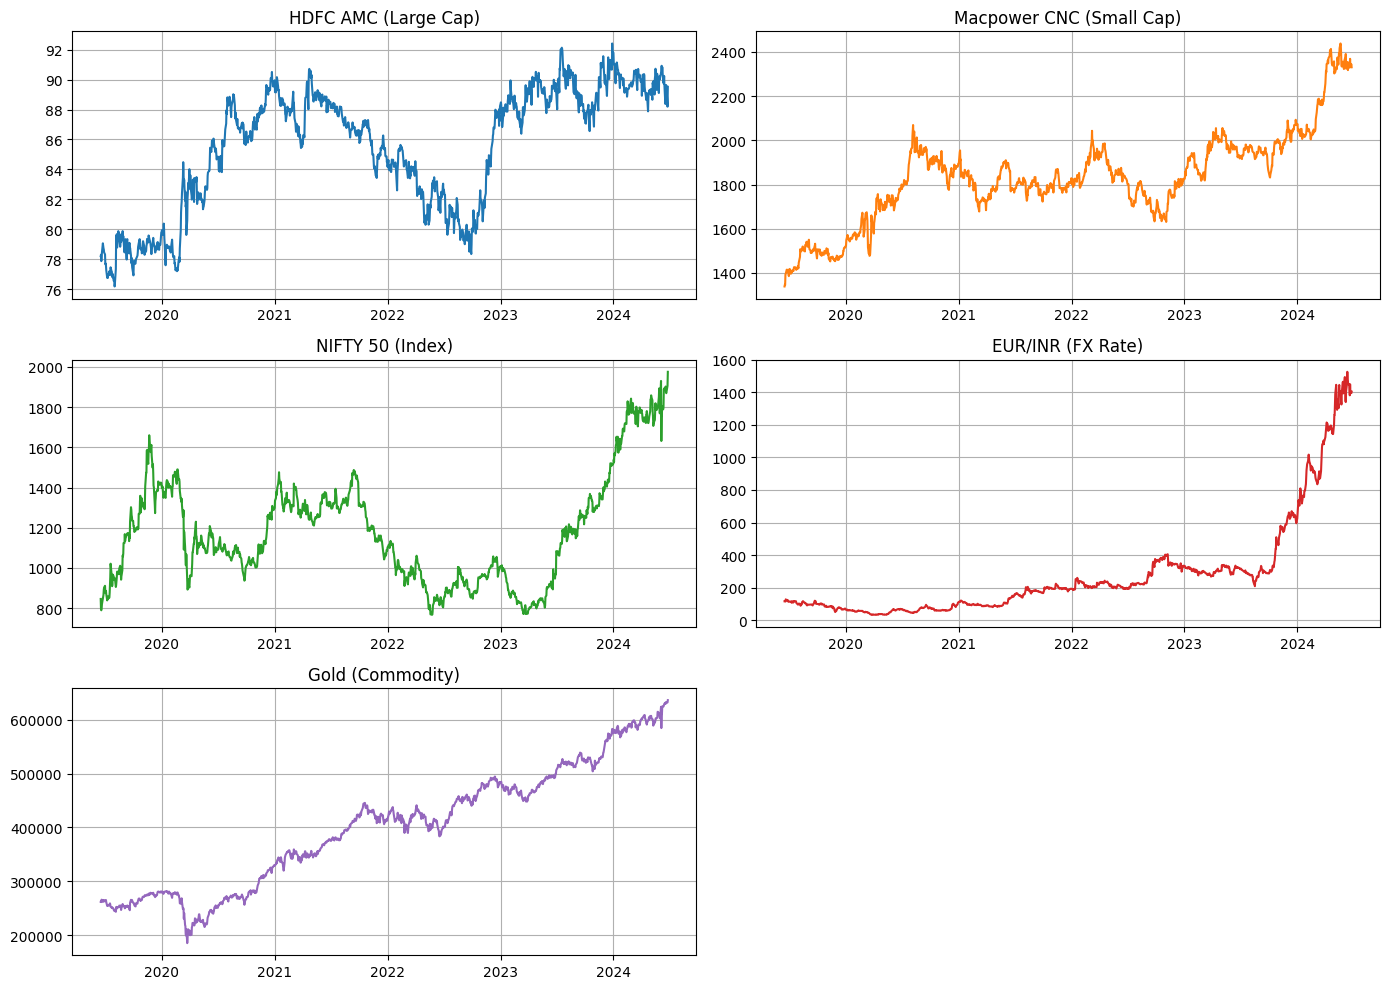

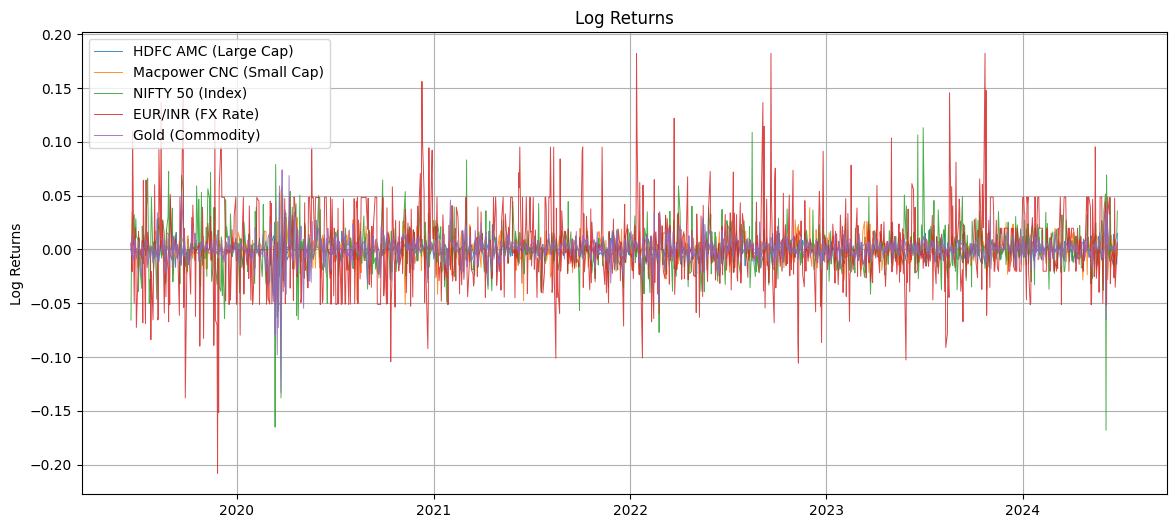

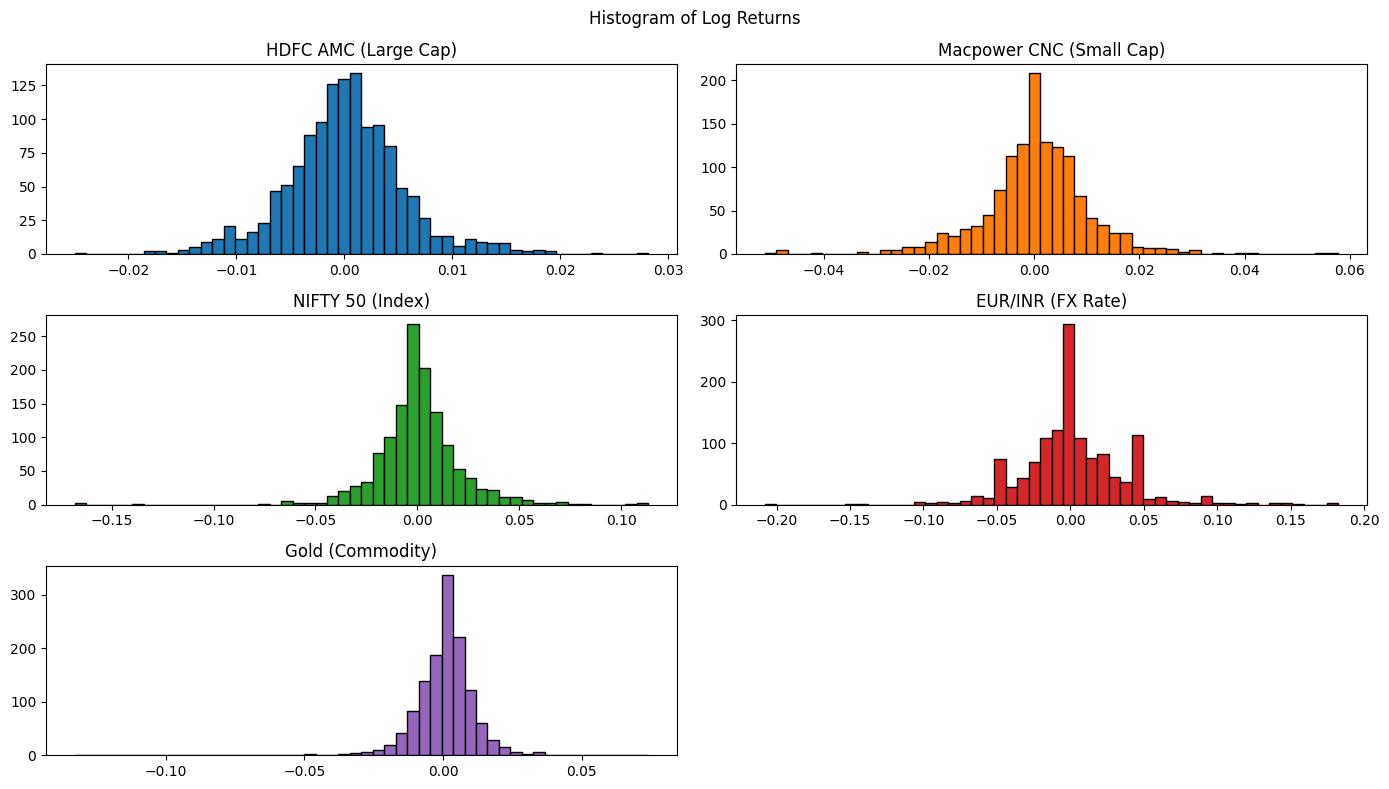

In [53]:
# Forward fill to handle missing values
data_ffill = data.ffill().dropna()

# Calculate daily log returns
returns = np.log(data_ffill / data_ffill.shift(1)).dropna()

# Fixed color per asset, reused across every chart below so the same asset
# always has the same color (tab10 palette - 5 clearly distinguishable colors)
asset_colors = dict(zip(data_ffill.columns, plt.cm.tab10.colors[:len(data_ffill.columns)]))

# Plot price history (raw values, native units)
fig, ax = plt.subplots(figsize=(14, 6))
for col in data_ffill.columns:
    ax.plot(data_ffill.index, data_ffill[col], label=col, color=asset_colors[col], lw=1.1)
ax.set_title("Asset Prices")
ax.set_ylabel("Price")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Extra graph: each asset in its own panel, in native units (NIFTY ~20,000
# points dwarfs EUR/INR ~90 on the combined chart above, so this makes the
# smaller-scale series readable too)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), data_ffill.columns):
    ax.plot(data_ffill.index, data_ffill[col], color=asset_colors[col])
    ax.set_title(col)
    ax.grid(True)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

# Plot return history
fig, ax = plt.subplots(figsize=(14, 6))
for col in returns.columns:
    ax.plot(returns.index, returns[col], label=col, color=asset_colors[col], lw=0.7, alpha=0.85)
ax.set_title("Log Returns")
ax.set_ylabel("Log Returns")
ax.grid(True)
ax.legend(loc="upper left")
plt.show()

# Plot histograms of returns
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), returns.columns):
    ax.hist(returns[col], bins=50, edgecolor='black', color=asset_colors[col])
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.suptitle("Histogram of Log Returns")
plt.tight_layout()
plt.show()

In [54]:
# merge all the returns into a single DataFrame
returns_df = pd.DataFrame(returns)
returns_df.columns = tickers.keys()
from scipy.stats import skew, kurtosis

data = returns_df.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

,Date,HDFC AMC (Large Cap),Macpower CNC (Small Cap),NIFTY 50 (Index),EUR/INR (FX Rate),Gold (Commodity)
0,2019-06-18,0.001304,0.005884,-0.065545,0.004910,0.006546
1,2019-06-19,-0.005494,-0.001486,-0.003461,0.000000,-0.004973
2,2019-06-20,0.003922,0.035291,0.010127,-0.020619,0.013433
3,2019-06-21,0.003461,0.002366,0.027645,0.110348,-0.010429
4,2019-06-24,0.007771,0.012881,0.032372,-0.049723,-0.005103
...,...,...,...,...,...,...
1308,2024-06-19,-0.001966,0.000000,-0.015456,-0.026474,-0.003410
1309,2024-06-20,0.001754,0.009373,-0.002079,0.047737,0.002711
1310,2024-06-21,-0.002391,-0.016085,0.005279,-0.035089,-0.000620
1311,2024-06-24,-0.013577,0.005646,0.014236,-0.002995,0.001095


In [55]:
# Task 2 : Printing the summary statistics upto 2 decimal points
for col in returns_df.columns:
    print(f"Summary statistics for {col}:")
    print(f"Mean: {returns_df[col].mean():.5f}")
    print(f"Standard Deviation: {returns_df[col].std():.2f}")
    print(f"Skewness: {skew(returns_df[col]):.2f}")
    print(f"Kurtosis: {kurtosis(returns_df[col]):.2f}")
    print("-" * 50)

Summary statistics for HDFC AMC (Large Cap):
Mean: 0.00010
Standard Deviation: 0.01
Skewness: 0.19
Kurtosis: 1.84
--------------------------------------------------
Summary statistics for Macpower CNC (Small Cap):
Mean: 0.00042
Standard Deviation: 0.01
Skewness: -0.19
Kurtosis: 4.06
--------------------------------------------------
Summary statistics for NIFTY 50 (Index):
Mean: 0.00065
Standard Deviation: 0.02
Skewness: -0.47
Kurtosis: 10.18
--------------------------------------------------
Summary statistics for EUR/INR (FX Rate):
Mean: 0.00190
Standard Deviation: 0.04
Skewness: 0.43
Kurtosis: 3.70
--------------------------------------------------
Summary statistics for Gold (Commodity):
Mean: 0.00068
Standard Deviation: 0.01
Skewness: -1.66
Kurtosis: 21.00
--------------------------------------------------


In [56]:
# Task 3 - Performing Volatility estimation using Historical Volatility Method and GARCH-type models
portfolio_weights = np.array([0.2] * len(returns_df.columns))  # Equal weights for each asset
portfolio_returns = returns_df.dot(portfolio_weights)
portfolio_returns_df = pd.DataFrame(portfolio_returns, columns=["Portfolio Returns"])

# print the mean std skewness and kurtosis of the portfolio returns
print(f"Summary statistics for the portfolio:")
print(f"Mean: {portfolio_returns_df['Portfolio Returns'].mean():.5f}")
print(f"Standard Deviation: {portfolio_returns_df['Portfolio Returns'].std():.5f}")
print(f"Skewness: {skew(portfolio_returns_df['Portfolio Returns']):.2f}")
print(f"Kurtosis: {kurtosis(portfolio_returns_df['Portfolio Returns']):.2f}")
print("-" * 50)

portfolio_returns_df

Summary statistics for the portfolio:
Mean: 0.00075
Standard Deviation: 0.01025
Skewness: -0.47
Kurtosis: 4.00
--------------------------------------------------


,Portfolio Returns
Date,
2019-06-18,-0.009380
2019-06-19,-0.003083
2019-06-20,0.008431
2019-06-21,0.026678
2019-06-24,-0.000361
...,...
2024-06-19,-0.009461
2024-06-20,0.011899
2024-06-21,-0.009781


### Task 3 - Volatility Modeling and Forecasting
- Finding the best ARIMA Model by comparing BIC scores
- Testing for Heteroskedasticity using GARCH models
- Forecasting volatility for 30 days
- Interpretation of the output

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8294.308, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8296.779, Time=0.12 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8296.333, Time=0.15 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-8298.643, Time=0.10 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-8297.080, Time=0.64 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-8297.486, Time=0.68 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-8299.158, Time=0.47 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-8297.429, Time=0.58 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-8298.027, Time=0.47 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-8295.480, Time=0.56 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8302.251, Time=0.95 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8300.689, Time=0.46 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8301.033, Time=1.41 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-8300.732, Time=1.13 sec
 ARIMA(1,0,2)(0,0,0

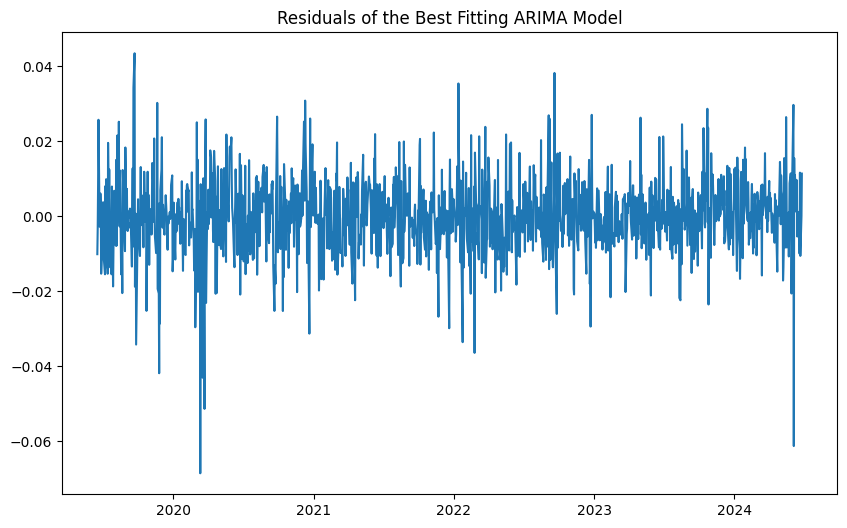

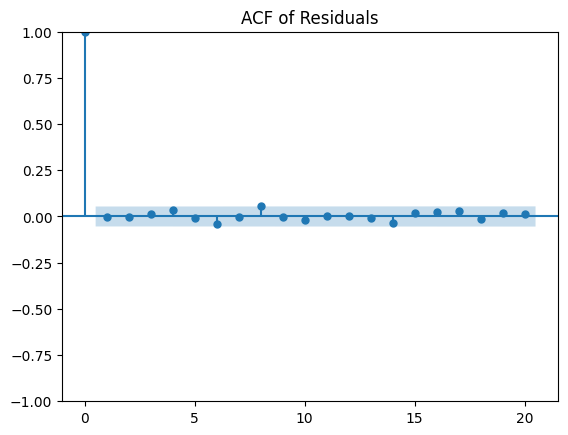

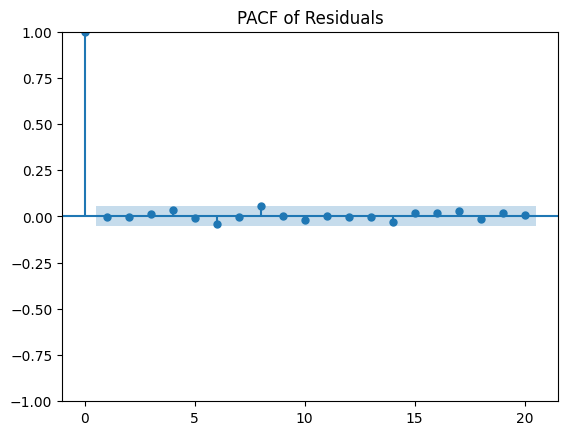

In [57]:
# Modeling the returns using ARIMA 
import pmdarima as pm

# Assuming 'data' and 'returns' are defined from the previous code
returns = portfolio_returns_df['Portfolio Returns'].dropna()

# Find best ARIMA model
# NOTE: information_criterion defaults to 'aic' here (not 'bic').
# BIC's penalty term is log(n) per extra parameter vs AIC's flat 2 per
# parameter, so on a return series with 1000+ observations BIC penalizes
# extra AR/MA terms much more harshly and tends to under-fit the mean
# equation. AIC is the more standard choice for picking a forecasting model.
arima_model = pm.auto_arima(returns, start_p=0, start_q=0,
                           max_p=5, max_q=5, m=1,
                           start_P=0, seasonal=False,
                           d=None, D=0, trace=True,
                           error_action='ignore',  # we don't want to know if an order does not work
                           suppress_warnings=True,  # we don't want convergence warnings
                           stepwise=True)

# Print the model summary
print(arima_model.summary())

# Get the residuals
residuals = arima_model.resid()

# Analyze the residuals (e.g., plot them, check for autocorrelation)
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals of the Best Fitting ARIMA Model")
plt.show()

# Further analysis on residuals (e.g., ACF, PACF plots)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

plot_pacf(residuals, lags=20)
plt.title("PACF of Residuals")
plt.show()

In [58]:
# performing tests for checking for hetersoskedasticity
import statsmodels.api as sm

# Assuming 'residuals' from the ARIMA model is available
# Perform the Breusch-Pagan test for heteroskedasticity
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, exog_het=sm.add_constant(np.arange(len(residuals))))

# Print the test results
print("\nBreusch-Pagan Test for Heteroskedasticity:")
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
for label, value in zip(labels, bp_test):
    print(f"{label}: {value}")

# Interpretation
alpha = 0.05  # Significance level
if bp_test[1] < alpha:
    print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


# Alternatively, you can use the Goldfeld-Quandt test
gq_test = sm.stats.diagnostic.het_goldfeldquandt(residuals, x=sm.add_constant(np.arange(len(residuals))))

print("\nGoldfeld-Quandt Test for Heteroskedasticity:")
print(f"F-statistic: {gq_test[0]}")
print(f"p-value: {gq_test[1]}")

if gq_test[1] < alpha:
  print("Reject the null hypothesis. Heteroskedasticity is present in the residuals.")
else:
  print("Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.")


Breusch-Pagan Test for Heteroskedasticity:
Lagrange multiplier statistic: 9.473927497068567
p-value: 0.0020841269425173115
f-value: 9.528247428767108
f p-value: 0.0020657556003876054
Reject the null hypothesis. Heteroskedasticity is present in the residuals.

Goldfeld-Quandt Test for Heteroskedasticity:
F-statistic: 0.7697504387002866
p-value: 0.9995829982612381
Fail to reject the null hypothesis. Heteroskedasticity is not present in the residuals.


In [59]:
# Assuming 'residuals' from the ARIMA model is available
# Perform the ARCH test for conditional heteroskedasticity
arch_test = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[10], return_df=True) # Test on squared residuals

# Print the test results
print("\nARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):")
print(arch_test)

# Interpretation
alpha = 0.05  # Significance level
if arch_test['lb_pvalue'][10] < alpha:
    print("Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.")
else:
    print("Fail to reject the null hypothesis. Conditional heteroskedasticity is not present in the residuals.")


ARCH Test for Conditional Heteroskedasticity (Ljung-Box test on squared residuals):
       lb_stat     lb_pvalue
10  145.051536  3.877010e-26
Reject the null hypothesis. Conditional heteroskedasticity is present in the residuals.


- According to the Breusch-Pagan test and ARCH Test (Ljung-Box), conditional heteroskedasticity is present in the time-series
-This leads to modelling of volatility

In [60]:
import arch

# Assuming 'residuals' from the ARIMA model is available
# Fit different GARCH models
garch_models = {
    'Standard GARCH': arch.arch_model(residuals, vol='Garch', p=1, q=1),
    'EGARCH': arch.arch_model(residuals, vol='EGARCH', p=1, o=1, q=1),
    'GJR-GARCH': arch.arch_model(residuals, vol='GARCH', p=1, o=1, q=1),  # GJR is a special case of GARCH
    'APARCH': arch.arch_model(residuals, vol='APARCH', p=1, o=1, q=1),
    'FIGARCH': arch.arch_model(residuals, vol='FIGARCH', p=1, o=1, q=1)
}

results = {}
for name, model in garch_models.items():
    try:
        results[name] = model.fit(disp='off')  # Fit the model (suppress output)
        print(f"Successfully fit {name}")
    except Exception as e:
        print(f"Error fitting {name}: {e}")

# Compare AIC/BIC to find the best fitting model
best_model_name = None
best_aic = float('inf')
best_bic = float('inf')

for name, result in results.items():
    if result.aic < best_aic:
        best_aic = result.aic
        best_model_name = name
    if result.bic < best_bic:
        best_bic = result.bic
for name, result in results.items():
    print(f"{name}: AIC = {result.aic:.2f}, BIC = {result.bic:.2f}")
print(f"Best Model (by AIC): {best_model_name}")


# Get residuals from the best GARCH model
if best_model_name in results:
    best_model_result = results[best_model_name]
    best_garch_residuals = best_model_result.std_resid
else:
    print("Best model not found in results!")
    best_garch_residuals = None

egarch_params=results['EGARCH'].params
print(egarch_params)
    
# print(results)

Successfully fit Standard GARCH
Successfully fit EGARCH
Successfully fit GJR-GARCH
Successfully fit APARCH
Successfully fit FIGARCH
Standard GARCH: AIC = -8412.44, BIC = -8391.72
EGARCH: AIC = -8410.52, BIC = -8384.62
GJR-GARCH: AIC = -8410.59, BIC = -8384.69
APARCH: AIC = -8411.90, BIC = -8380.81
FIGARCH: AIC = -8402.84, BIC = -8376.94
Best Model (by AIC): Standard GARCH
mu         -0.000009
omega      -1.185595
alpha[1]    0.260616
gamma[1]   -0.020673
beta[1]     0.870336
Name: params, dtype: float64


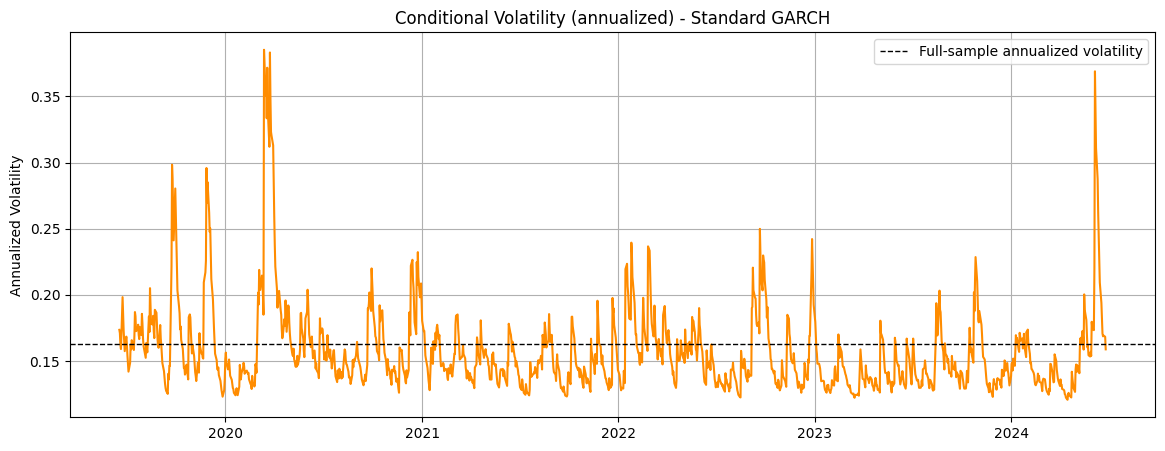

In [61]:
# Extra graph - annualized conditional volatility from the best-fit GARCH model
cond_vol_annual = best_model_result.conditional_volatility * np.sqrt(252)
plt.figure(figsize=(14, 5))
plt.plot(cond_vol_annual.index, cond_vol_annual, color='darkorange')
plt.axhline(portfolio_returns_df['Portfolio Returns'].std() * np.sqrt(252),
            color='black', linestyle='--', lw=1, label='Full-sample annualized volatility')
plt.title(f"Conditional Volatility (annualized) - {best_model_name}")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# We simulate as follows for each day, define r_t=sigma_t X z_t , now sample 1000 z's to get 1000 returns
# now std dev of this 1000 observations is essentially vol/sqrt(252) and thus it yileds vol1, do these 30 times
forecast_horizon = 30
num_simulations = 1000

# 1) Run a simulation‑based forecast
fc = best_model_result.forecast(
    horizon=forecast_horizon,
    method='simulation',
    simulations=num_simulations
)

# fc.simulations is an (horizon × simulations) array of returns
simulated_returns = fc.simulations.values*np.sqrt(252)
# for daily volatility, we simply use the fc.simulations.values  

# 2) Compute daily vol as the std‑dev across the simulation axis
volatility_forecast = simulated_returns.std(axis=1)
volatility_forecast = volatility_forecast.ravel()

# 3) Put into a DataFrame for easy viewing
volatility_forecast_df = pd.DataFrame({
    "Day": np.arange(1, forecast_horizon + 1),
    "Volatility Forecast": volatility_forecast
})

print("\nAnnual volatility Forecast for the Next 30 Days:")
volatility_forecast_df.set_index("Day", inplace=True)
volatility_forecast_df


Annual volatility Forecast for the Next 30 Days:


,Volatility Forecast
Day,
1,0.159186
2,0.160318
3,0.155689
4,0.160870
5,0.168594
6,0.159248
7,0.160312
8,0.160034
9,0.158993


### Task 4 : Value at Risk (VaR) Estimation
- 1-day and 10-day VaR estimation using all 3 methods
- Interpretations and Assumptions

In [63]:
VaR_results = pd.DataFrame(columns=["Simulation Method","VaR_95_1_day", "VaR_99_1_day", "VaR_95_10_day", "VaR_99_10_day"])

In [64]:
# Task 4 - VaR Estimation using 3 methods


# HISTORICAL SIMULATION METHOD
def compute_var_bootstrap(returns, confidence_level, num_simulations=1000):
    var_values = []
    for _ in range(num_simulations):
        # Perform bootstrapping by resampling returns with replacement
        bootstrapped_returns = np.random.choice(returns, size=len(returns), replace=True)

        # Sort the bootstrapped returns
        sorted_returns = np.sort(bootstrapped_returns)

        # Calculate the index corresponding to the desired quantile
        index = int(len(sorted_returns) * (1 - confidence_level))

        # Extract the VaR at the specified confidence level
        var = -sorted_returns[index]
        var_values.append(var)

    # Calculate the mean VaR and the 95% confidence interval
    mean_var = np.mean(var_values)
    lower_bound = np.percentile(var_values, 2.5)
    upper_bound = np.percentile(var_values, 97.5)

    return mean_var, lower_bound, upper_bound

# Compute VaR at 95% and 99% confidence levels
var_95_mean, var_95_lower, var_95_upper = compute_var_bootstrap(returns, 0.95)
var_99_mean, var_99_lower, var_99_upper = compute_var_bootstrap(returns, 0.99)


print(f"95% VaR (Mean) - (one-day) - Historical Simulation: {var_95_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_95_mean*np.sqrt(10):.4f}")
# print(f"95% VaR Confidence Interval: ({var_95_lower:.4f}, {var_95_upper:.4f})")
print(f"99% VaR (Mean) - (one-day) - Historical Simulation: {var_99_mean:.4f}")
print(f"95% VaR (Mean) - (ten-day) - Historical Simulation: {var_99_mean*np.sqrt(10):.4f}")
# print(f"99% VaR Confidence Interval: ({var_99_lower:.4f}, {var_99_upper:.4f})")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Historical Simulation", "VaR_95_1_day": var_95_mean, "VaR_99_1_day": var_99_mean,"VaR_95_10_day": var_95_mean*np.sqrt(10), "VaR_99_10_day": var_99_mean*np.sqrt(10)}])], ignore_index=True)

95% VaR (Mean) - (one-day) - Historical Simulation: 0.0146
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0460
99% VaR (Mean) - (one-day) - Historical Simulation: 0.0279
95% VaR (Mean) - (ten-day) - Historical Simulation: 0.0884


In [65]:
# USING VARIANCE-COVARIANCE VAR METHOD

from scipy import stats

def parametric_var(returns, confidence_level, lookback_period=252):
    """
    Computes Parametric Value at Risk (VaR) using the variance-covariance method.

    Args:
        returns (pd.Series): A pandas Series of historical returns.
        confidence_level (float): The desired confidence level for VaR (e.g., 0.95 for 95% VaR).
        lookback_period (int): The number of past returns to use for estimation.

    Returns:
        float: The calculated VaR value.
    """
    # Calculate the mean and standard deviation of returns over the lookback period.
    mean_return = returns.tail(lookback_period).mean()
    std_dev_return = returns.tail(lookback_period).std()

    # Calculate the z-score corresponding to the confidence level.
    z_score = np.abs(stats.norm.ppf(1 - confidence_level))

    # Calculate VaR using the formula: VaR = mean_return - z_score * std_dev_return
    var = -(mean_return - z_score * std_dev_return)

    return var

# Example usage with your existing returns data:
# Assuming 'returns' is a pandas Series of your daily returns
confidence_level = 0.95  # 95% confidence level
var_95 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_95:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (ten-day): {var_95*np.sqrt(10):.4f}")
# For 99% confidence level
confidence_level = 0.99
var_99 = parametric_var(returns, confidence_level)
print(f"{confidence_level*100:.0f}% Parametric VaR (one-day): {var_99:.4f}")
print(f"{confidence_level*100:.0f}% Parametric VaR (teb-day): {var_99*np.sqrt(10):.4f}")
VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Parametric VaR", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)

95% Parametric VaR (one-day): 0.0137
95% Parametric VaR (ten-day): 0.0432
99% Parametric VaR (one-day): 0.0202
99% Parametric VaR (teb-day): 0.0638


In [66]:
# MONTE - CARLO SIMULATIONS METHOD
# lookback period is 252 (1 year) since Basel Comimittee finacnial frameworks explicitly reuqire banks to compute parametric VaR
# using 1 year lookback period,ie, its a industry standard

# find the best fitting distribution
import scipy.stats as st
from scipy.stats import genextreme as gev, genpareto as gpd

def fit_distributions(returns, distributions):
    results = {}
    for distribution_name in distributions:
        try:
            distribution = getattr(st, distribution_name)
            params = distribution.fit(returns)
            results[distribution_name] = {
                'distribution': distribution,
                'params': params,
                'AIC': distribution.nnlf(params, returns) + 2 * len(params),  # AIC
                'BIC': distribution.nnlf(params, returns) + len(params) * np.log(len(returns))  # BIC
            }
        except Exception as e:
            print(f"Error fitting {distribution_name}: {e}")
            continue

    return results

def compare_distributions(results):
    best_distribution = None
    best_aic = float('inf')
    best_bic = float('inf')  # Initialize best_bic to infinity
    for name, result in results.items():
        if result['AIC'] < best_aic:
            best_aic = result['AIC']
            best_distribution = name
        if result['BIC'] < best_bic:  # Compare BIC as well
            best_bic = result['BIC']

    print(f"\nComparison of Distribution Fits:")
    for name, result in results.items():
        print(f"{name}: AIC = {result['AIC']:.2f}, BIC = {result['BIC']:.2f}")  # Print both AIC and BIC
    print(f"Best Distribution by AIC: {best_distribution}")  # Explicitly print by AIC

    # Return AIC and BIC of the best distribution for clarity
    return best_distribution, results[best_distribution]['AIC'], results[best_distribution]['BIC']

# Step 2: Define Distributions to Fit
distributions = [
    'norm', 't', 'cauchy', 'laplace', 'logistic',
    'gumbel_r', 'gumbel_l', 'hypsecant', 'gennorm', 'skewnorm',
    'johnsonsu', 'johnsonsb'
]
distributions.extend(['genextreme', 'genpareto'])  # Add GEV and GPD

# Fit distributions
fitted_distributions = fit_distributions(returns, distributions)
best_dist, best_aic, best_bic = compare_distributions(fitted_distributions)

print(f"\nBest Distribution (AIC): {best_dist}, AIC={best_aic:.2f}, BIC={best_bic:.2f}") # Displaying the best distribution


Comparison of Distribution Fits:
norm: AIC = -4147.65, BIC = -4137.29
t: AIC = -4218.53, BIC = -4202.98
cauchy: AIC = -4082.15, BIC = -4071.79
laplace: AIC = -4213.94, BIC = -4203.58
logistic: AIC = -4211.17, BIC = -4200.81
gumbel_r: AIC = -3773.87, BIC = -3763.51
gumbel_l: AIC = -4009.59, BIC = -3999.23
hypsecant: AIC = -4218.20, BIC = -4207.84
gennorm: AIC = -4215.52, BIC = -4199.98
skewnorm: AIC = -4155.51, BIC = -4139.97
johnsonsu: AIC = -4216.63, BIC = -4195.91
johnsonsb: AIC = -4150.21, BIC = -4129.49
genextreme: AIC = -2322.82, BIC = -2307.28
genpareto: AIC = -2854.02, BIC = -2838.48
Best Distribution by AIC: t

Best Distribution (AIC): t, AIC=-4218.53, BIC=-4202.98


In [67]:
import numpy as np
from scipy.stats import t

def monte_carlo_var(returns, confidence_level, num_simulations=10000, best_dist='t', dist_params=None):
    if best_dist == 't':
        if dist_params is None:
            raise ValueError("Distribution parameters are required for t-distribution")
        df, loc, scale = dist_params  # Extract t-distribution parameters
        simulated_returns = t.rvs(df, loc=loc, scale=scale, size=num_simulations)
    else:
        raise ValueError("Unsupported distribution")

    var = -np.percentile(simulated_returns, 100 * (1 - confidence_level))
    return var

# Example: Access parameters for the t-distribution (replace 't' with your best_dist if different)
if 't' in fitted_distributions:
  t_params = fitted_distributions['t']['params']
  var_95 = monte_carlo_var(returns, 0.95, best_dist='t', dist_params=t_params)
  var_99 = monte_carlo_var(returns, 0.99, best_dist='t', dist_params=t_params)
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95:.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_95*np.sqrt(10):.4f}")
  print(f"95% VaR (Monte Carlo, t-distribution): {var_99:.4f}")
  print(f"99% VaR (Monte Carlo, t-distribution): {var_99*np.sqrt(10):.4f}")
else:
  print("t distribution not found in fitted distributions")

VaR_results = pd.concat([VaR_results, pd.DataFrame([{"Simulation Method": "Monte-Carlo Simulation", "VaR_95_1_day": var_95, "VaR_99_1_day": var_99,"VaR_95_10_day": var_95*np.sqrt(10), "VaR_99_10_day": var_99*np.sqrt(10)}])], ignore_index=True)

95% VaR (Monte Carlo, t-distribution): 0.0151
95% VaR (Monte Carlo, t-distribution): 0.0476
95% VaR (Monte Carlo, t-distribution): 0.0260
99% VaR (Monte Carlo, t-distribution): 0.0821


In [68]:
VaR_results

,Simulation Method,VaR_95_1_day,VaR_99_1_day,VaR_95_10_day,VaR_99_10_day
0,Historical Simulation,0.014551,0.027946,0.046015,0.088375
1,Parametric VaR,0.013673,0.02017,0.043238,0.063784
2,Monte-Carlo Simulation,0.015053,0.025958,0.047602,0.082086


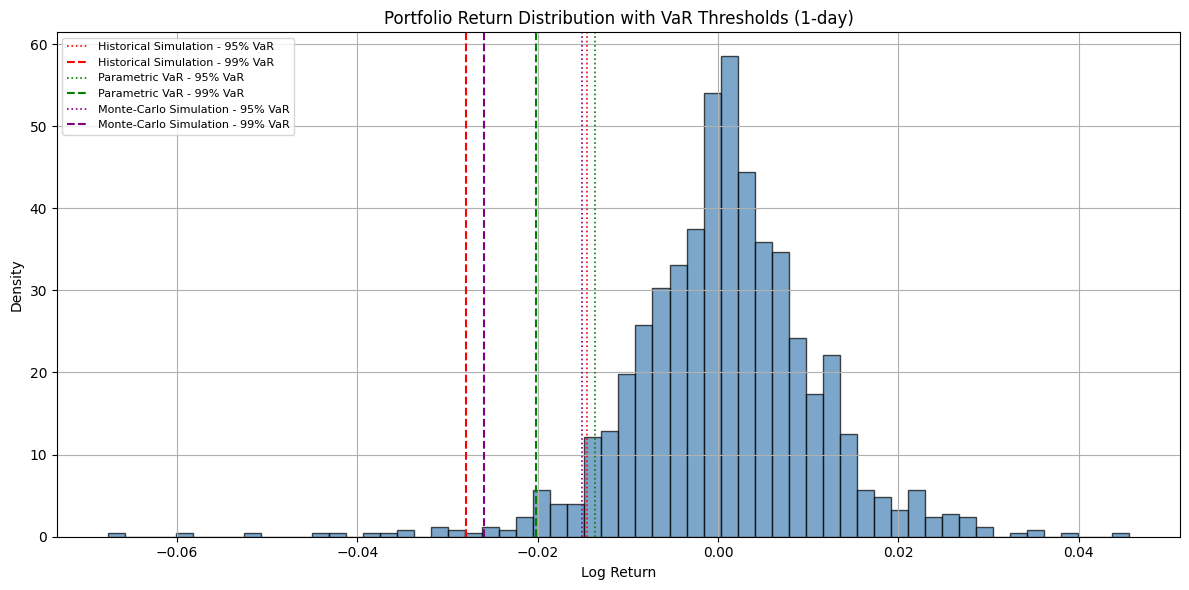

In [69]:
# Extra graph - portfolio return histogram with the 95%/99% VaR thresholds overlaid
plt.figure(figsize=(12, 6))
plt.hist(returns, bins=60, color='steelblue', edgecolor='black', alpha=0.7, density=True)

colors = {'Historical Simulation': 'red', 'Parametric VaR': 'green', 'Monte-Carlo Simulation': 'purple'}
for _, row in VaR_results.iterrows():
    c = colors.get(row['Simulation Method'], 'black')
    plt.axvline(-row['VaR_95_1_day'], color=c, linestyle=':', lw=1.2,
                label=f"{row['Simulation Method']} - 95% VaR")
    plt.axvline(-row['VaR_99_1_day'], color=c, linestyle='--', lw=1.5,
                label=f"{row['Simulation Method']} - 99% VaR")

plt.title("Portfolio Return Distribution with VaR Thresholds (1-day)")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.legend(fontsize=8, ncol=1, loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### The above results indicate the following : 
- 99% VaR > 95% always for the same method since it gives a more risk-sensitive estimate
- Parametric VaR method underpredicts the 1-day and 10-day VaR values since Normal Distribution is not the best fit
- Hisstorical simulation gives VaR estimates that are close to the Monte-Carlo approach, but overpredict the 99% VaR 

### Task 5 - Backtesting and Model Validation


In [70]:
import numpy as np
from scipy.stats import t, norm, chi2
from statsmodels.stats.diagnostic import acorr_ljungbox

def kupiec_test(violations: int, total_obs: int, p_exceed: float) -> float:
    """
    Kupiec POF test (proportion of failures).
    
    violations   = number of observed exceptions (x)
    total_obs    = number of VaR forecasts (T)
    p_exceed     = expected exception probability (e.g. 0.05 for 95% VaR)
    
    Returns the p‑value of LR = -2[ log L0 – log L1 ] ~ χ²(1).
    """
    x, T = violations, total_obs
    # avoid log(0) by handling edge cases
    term1 = x * np.log(p_exceed / (x / T))             if x > 0 else 0
    term2 = (T - x) * np.log((1 - p_exceed) / ((T - x) / T)) if T - x > 0 else 0
    LR = -2 * (term1 + term2)
    p_value = 1 - chi2.cdf(LR, df=1)
    return round(p_value, 5)


def christoffersen_test(actual_violations, alpha=0.05):
    """
    Christoffersen test for VaR model accuracy.  Checks for independence of violations.

    Args:
        actual_violations: A series of 1s (violations) and 0s (no violations)
        alpha: Significance level.

    Returns:
        p_value: p-value of the test.
    """
    # Calculate the number of violations
    num_violations = actual_violations.sum()

    # Perform Ljung-Box test on indicator series
    test_result = acorr_ljungbox(actual_violations, lags=1, return_df=True)  # Lag of 1 is sufficient for this test
    p_value = test_result['lb_pvalue'][1]
    return p_value


def christoffersen_joint_test(violations, p=0.01, alpha=0.05):
    """
    Christoffersen (1998) Conditional Coverage Backtest
    violations: pd.Series or np.array of 0s and 1s
    p: expected failure rate (e.g., 0.01 for 99% VaR)
    """
    v = np.asarray(violations)
    N = len(v)
    
    # --- 1. Unconditional Coverage (Kupiec LR_uc) ---
    x = v.sum() # Total violations
    # Likelihood under null hypothesis
    L_null = (p ** x) * ((1 - p) ** (N - x))
    # Likelihood under alternative
    p_hat = x / N
    L_alt = (p_hat ** x) * ((1 - p_hat) ** (N - x))
    
    LR_uc = -2 * np.log(L_null / L_alt) if L_alt > 0 else 0
    p_val_uc = 1 - stats.chi2.cdf(LR_uc, df=1)

    # --- 2. Independence Test (Christoffersen LR_ind) ---
    # Transition counts
    n00 = np.sum((v[:-1] == 0) & (v[1:] == 0))
    n01 = np.sum((v[:-1] == 0) & (v[1:] == 1))
    n10 = np.sum((v[:-1] == 1) & (v[1:] == 0))
    n11 = np.sum((v[:-1] == 1) & (v[1:] == 1))
    
    pi_0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi_1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi_2 = (n01 + n11) / (n00 + n01 + n10 + n11)
    
    L_ind_null = ((1 - pi_2)**(n00 + n10)) * (pi_2**(n01 + n11))
    L_ind_alt = ((1 - pi_0)**n00) * (pi_0**n01) * ((1 - pi_1)**n10) * (pi_1**n11)
    
    LR_ind = -2 * np.log(L_ind_null / L_ind_alt) if L_ind_alt > 0 else 0
    p_val_ind = 1 - stats.chi2.cdf(LR_ind, df=1)

    # --- 3. Combined Conditional Coverage (LR_cc) ---
    LR_cc = LR_uc + LR_ind
    p_val_cc = 1 - stats.chi2.cdf(LR_cc, df=2)

    return {
        "LR_uc (Kupiec)": [LR_uc, p_val_uc],
        "LR_ind (Independence)": [LR_ind, p_val_ind],
        "LR_cc (Joint)": [LR_cc, p_val_cc]
    }

In [71]:
# calculate the number of violations 
# print the acceptable number of violations according to var_95 and var_99
print(f"Acceptable number of violations for 95% VaR: {len(portfolio_returns_df) * 0.05:.2f}")
print(f"Acceptable number of violations for 99% VaR: {len(portfolio_returns_df) * 0.01:.2f}")
violations = (portfolio_returns_df['Portfolio Returns'] < -var_99).astype(int)  # Assuming var_99 is the VaR threshold
violations_ind = violations.astype(int)  # Convert violations to integers for statistical tests
print('Total number of violations:', violations.sum()) 

# Kupiec POF test
p_val_k = kupiec_test(violations.sum(), len(violations), 0.05)
print(f"Kupiec Test p‑value: {p_val_k}")
if(p_val_k < 0.05):
    print("Reject the null hypothesis. Too many violations. The model understates/overstates risk.")
else:
    print("Fail to reject the null hypothesis. Actual number of violations is consistent with expected VaR model.")
# Christoffersen test
p_val_c = christoffersen_test(violations_ind)
print(f"Christoffersen Test p-value: {p_val_c.round(5)}")
if(p_val_c < 0.05):
    print("Reject the null hypothesis. The violations are not independent.")
else:
    print("Fail to reject the null hypothesis. The violations are independent.")


p_val_cc=christoffersen_joint_test(violations, p=0.01, alpha=0.05)["LR_cc (Joint)"][1]
print(f"Christofferesen_joint Test p-value: {p_val_cc.round(5)}")
if(p_val_cc<0.05):
    print("Reject Null Hypothesis,i.e.,violations are not independent or risk under/overstated")
else:
    print("H0 true! ie Model is legally correct and passes all regulations!")

Acceptable number of violations for 95% VaR: 65.65
Acceptable number of violations for 99% VaR: 13.13
Total number of violations: 15
Kupiec Test p‑value: 0.0
Reject the null hypothesis. Too many violations. The model understates/overstates risk.
Christoffersen Test p-value: 0.67482
Fail to reject the null hypothesis. The violations are independent.
Christofferesen_joint Test p-value: 0.73928
H0 true! ie Model is legally correct and passes all regulations!


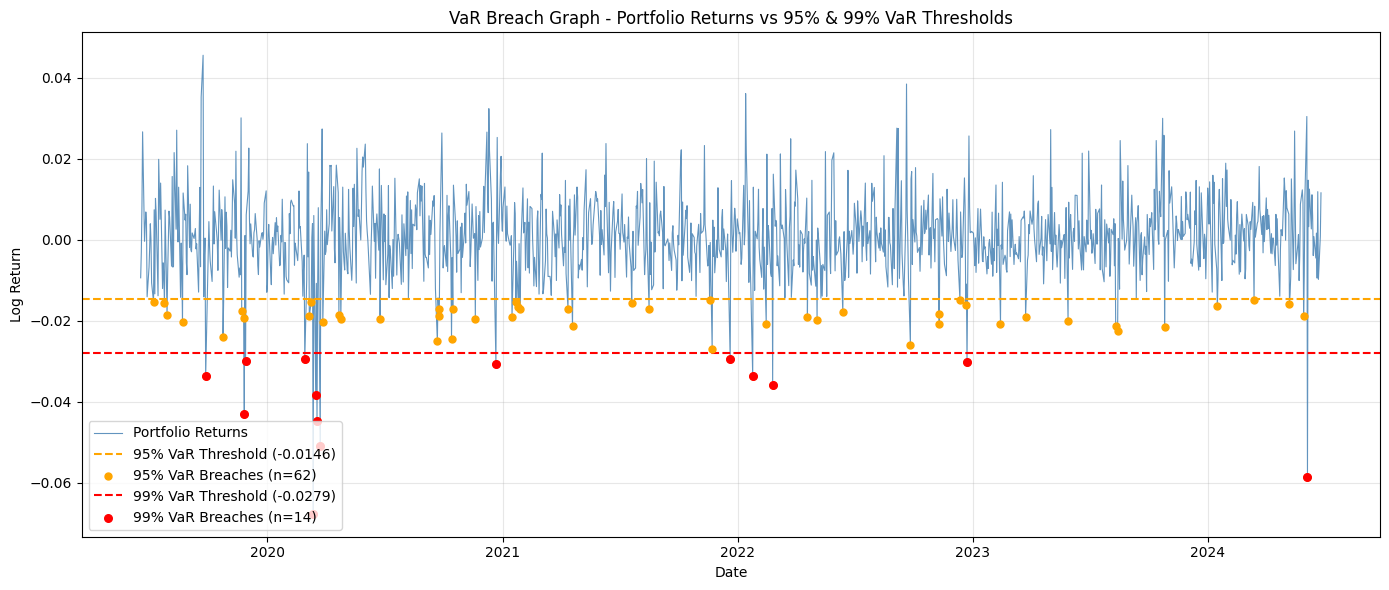

Total 95% VaR Breaches: 62 out of 1313 days
Expected 95% Breaches: 65
----------------------------------------
Total 99% VaR Breaches: 14 out of 1313 days
Expected 99% Breaches: 13


In [72]:
# 1. Calculate Thresholds and Identify Breaches
var_95_threshold = -var_95_mean 
breaches_95 = portfolio_returns_df[portfolio_returns_df['Portfolio Returns'] < var_95_threshold]

var_99_threshold = -var_99_mean
breaches_99 = portfolio_returns_df[portfolio_returns_df['Portfolio Returns'] < var_99_threshold]

# 2. Plotting Both 95% and 99% on the Same Chart
plt.figure(figsize=(14, 6))
plt.plot(portfolio_returns_df.index, portfolio_returns_df['Portfolio Returns'], 
         label='Portfolio Returns', color='steelblue', lw=0.8, alpha=0.85)

# Plot 95% Line & Scatter
plt.axhline(y=var_95_threshold, color='orange', linestyle='--', lw=1.5, 
            label=f'95% VaR Threshold ({var_95_threshold:.4f})')
plt.scatter(breaches_95.index, breaches_95['Portfolio Returns'], 
            color='orange', s=25, zorder=4, 
            label=f'95% VaR Breaches (n={len(breaches_95)})')

# Plot 99% Line & Scatter
plt.axhline(y=var_99_threshold, color='red', linestyle='--', lw=1.5, 
            label=f'99% VaR Threshold ({var_99_threshold:.4f})')
plt.scatter(breaches_99.index, breaches_99['Portfolio Returns'], 
            color='red', s=30, zorder=5, 
            label=f'99% VaR Breaches (n={len(breaches_99)})')

# Formatting
plt.title('VaR Breach Graph - Portfolio Returns vs 95% & 99% VaR Thresholds')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Print Summary Stats
print(f"Total 95% VaR Breaches: {len(breaches_95)} out of {len(portfolio_returns_df)} days")
print(f"Expected 95% Breaches: {int(len(portfolio_returns_df) * 0.05)}")
print("-" * 40)
print(f"Total 99% VaR Breaches: {len(breaches_99)} out of {len(portfolio_returns_df)} days")
print(f"Expected 99% Breaches: {int(len(portfolio_returns_df) * 0.01)}")

### Task 6 : (Option Pricing and Greek Sensitivities)
#### - Simulated the GBM Stock Prices for SBIN.NS (10,000 simulations) 
#### - Used GBM paths to compute Call/Put option prices
#### - Estimate Delta (finite differences), Gamma, Vega, Theta
#### - Compare the greeks for different strike prices (K) and Maturities (T)


In [73]:
import yfinance as yf
import numpy as np
import pandas as pd
# Task 6 - Option Pricing & Greek Sensitivities
ticker = 'SBIN.NS'  
# simulate GBM paths for
start_date = '2025-01-16' #Maa's Birhtday
end_date = '2025-01-25' #Harsh's Birthday
# use these paths to compute European call/put option prices and Greeks
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)["Adj Close"]
data = data.ffill().dropna()
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data

[*********************100%***********************]  1 of 1 completed


Ticker,Date,SBIN.NS
0,2025-01-16,737.914917
1,2025-01-17,735.796387
2,2025-01-20,750.385254
3,2025-01-21,730.933472
4,2025-01-22,725.540955
5,2025-01-23,718.270630
6,2025-01-24,716.585449


In [74]:
import random
import math
def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N  # Time step
    prices = [S0]  # List to store the stock prices, starting with the initial price
    for i in range(1, N):
        Z = random.gauss(0, 1)  # Generate a random number from a standard normal distribution
        price = prices[i-1] * math.exp((mu - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z)
        prices.append(price)
    return prices

# Function to simulate multiple paths
def simulate_multiple_paths(S0, mu, sigma, T, N, M):
    all_prices = []  # List to store multiple simulated paths
    for i in range(M):
        all_prices.append(simulate_gbm(S0, mu, sigma, T, N))  # Simulate each path
    return all_prices

# Function to visualize the simulated stock price paths
def plot_simulation_paths(all_prices):
    plt.figure(figsize=(10, 6))
    for path in all_prices:
        plt.plot(path, color='blue', alpha=0.1)  # Simulate multiple paths
    plt.title('SIMULATED GBM PATHS FOR SBI')
    plt.xlabel('Time Steps')
    plt.ylabel('Stock Price')
    plt.show()

In [75]:
# Fetch price specifically around January 16, 2025
sbi_jan16 = yf.download('SBIN.NS', start='2025-01-16', end='2025-01-17', auto_adjust=False)["Close"]

# Extract exact price scalar
S0 = float(sbi_jan16.iloc[0].item())
print(f"S0 price on 16-01-2025: {S0:.2f}")
returns = np.log(stock_data / stock_data.shift(1)).dropna()
mean_returns_sbi = returns.mean()*252
print("Mean Returns : ",mean_returns_sbi)
mean_std_sbi = returns.std()*np.sqrt(252)
print("Standard Deviation : ",mean_std_sbi)
print("S0 (16-01-2025 price) : ", S0)

[*********************100%***********************]  1 of 1 completed


S0 price on 16-01-2025: 766.30
Mean Returns :  Ticker
SBIN.NS   -1.231903
dtype: float64
Standard Deviation :  Ticker
SBIN.NS    0.235664
dtype: float64
S0 (16-01-2025 price) :  766.2999877929688


In [76]:

# GBM path simulator for stock
def simulate_gbm_paths(S0, mu, sigma, T, N, M, seed=None):
    """
    Simulate M GBM paths, each with N time-steps, over total horizon T (in years).
    Returns an (M, N+1) array of prices including S0 at t=0.
    """
    dt = T / N
    if seed is not None:
        np.random.seed(seed)
    # Standard normals: shape (M, N)
    Z = np.random.normal(size=(M, N))
    # Pre-allocate and set initial prices
    S = np.zeros((M, N+1))
    S[:, 0] = S0
    # Step forward
    for t in range(1, N+1):
        S[:, t] = S[:, t-1] * np.exp((mu - 0.5*sigma**2)*dt
                                       + sigma * np.sqrt(dt) * Z[:, t-1])
    return S
# Finding option prices
def price_european_call(S_paths, K, r, T):
    payoffs = np.maximum(S_paths[:, -1] - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)
def price_european_put(S_paths, K, r, T):
    payoffs = np.maximum(K-S_paths[:,-1],0)
    return np.exp(-r * T) * np.mean(payoffs)
# Option Greeks
def delta_fd(base_price_fn, bump):
    C0_call, _ = base_price_fn()
    C_plus_call, _ = base_price_fn(S0_bump=+bump)
    return (C_plus_call - C0_call) / bump

def gamma_fd(base_price_fn, bump):
    C_minus,_ = base_price_fn(S0_bump=-bump)
    C0_call,_      = base_price_fn()
    C_plus,_  = base_price_fn(S0_bump=+bump)
    return (C_plus - 2*C0_call + C_minus) / bump**2

def vega_fd(base_price_fn, bump):
    C_plus,_  = base_price_fn(sigma_bump=+bump)
    C_minus,_ = base_price_fn(sigma_bump=-bump)
    return (C_plus - C_minus) / (2*bump)

def theta_fd(base_price_fn, dt):
    # Theta ≈ (C(T - dt) - C(T)) / dt
    C_now,_    = base_price_fn()
    C_earlier,_ = base_price_fn(T_bump=-dt)
    return (C_earlier - C_now) / dt

def make_pricer(S0, mu, sigma, r, K, T, N, M, seed=42):
    def pricer(S0_bump=0.0, sigma_bump=0.0, T_bump=0.0):
        # adjust parameters
        S0_adj   = S0   + S0_bump
        sigma_adj= sigma+ sigma_bump
        T_adj    = T    + T_bump
        # If T changes, adjust N accordingly so dt=1/252
        N_adj    = int(np.round(T_adj * 252))
        paths = simulate_gbm_paths(S0_adj, mu, sigma_adj, T_adj, N_adj, M, seed)
        return price_european_call(paths, K, r, T_adj), price_european_put(paths, K, r, T_adj)
    return pricer

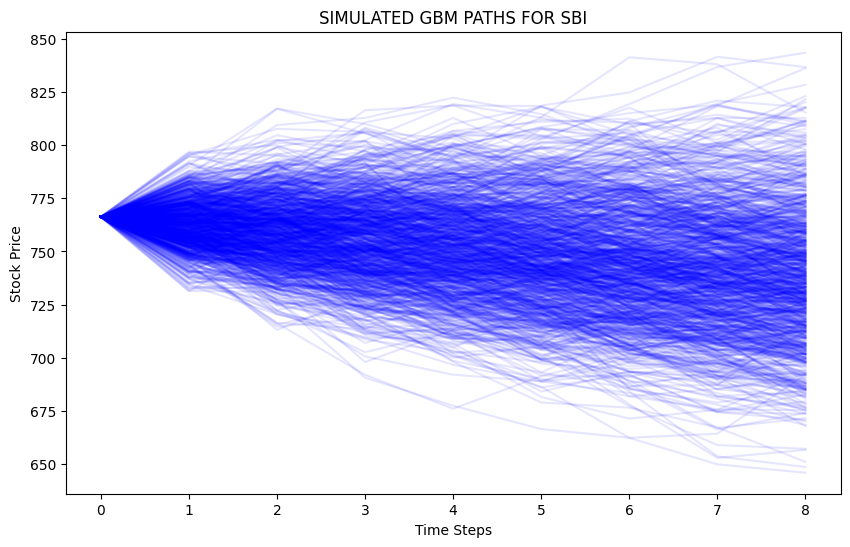

In [77]:
if __name__ == "__main__":
    
    # Convert parameters to scalar floats
    S0_val = float(S0.item()) if hasattr(S0, 'item') else float(S0)
    mu_val= float(mu.item()) if hasattr(mu, 'item') else float(mu)
    sigma_val = float(sigma.item()) if hasattr(sigma, 'item') else float(sigma)

# Run simulation with float scalars
    simulated_paths = simulate_multiple_paths(S0_val, mu_val, sigma_val, T_full, N_full, M)
    r     = 0.06              # annual risk-free rate
    # 9 trading days from 16 Apr to 25 Apr => T_full = 9/252
    N_full = 9
    T_full = N_full / 252
    M = 1000 # number of paths
    
    simulated_paths = simulate_multiple_paths(S0, mu, sigma, T_full, N_full, M)
    plot_simulation_paths(simulated_paths)
    
    # Strikes: 90%, 100%, 110% (for comparison across different strike prices)
    strikes = [0.9*S0, S0, 1.1*S0]

    # Maturities (for comparison across different maturities)
    maturity_steps = [N_full//3, 2*(N_full//3), N_full]
    maturities     = [n/252 for n in maturity_steps]

    seed = 42   # for reproducibility

    # Collect results
    results = []

    for T, step in zip(maturities, maturity_steps):
        N = step
        dt = 1/252
        for K in strikes:
            # Create a pricer closure for this (K, T)
            pricer = make_pricer(S0, mu, sigma, r, K, T, N, M, seed)

            # Base price
            C0_call, C0_put = pricer()

            # Greeks
            dS    = S0 * 1e-2     # 1% bump
            dsig  = sigma * 1e-2  # 1% vol bump
            Δ     = delta_fd(pricer, dS)
            Γ     = gamma_fd(pricer, dS)
            Vega  = vega_fd(pricer, dsig)
            Θ     = theta_fd(pricer, dt)

            results.append({
                'Maturity (days)':   N,
                'Strike':            K,
                'Price (Call)':             C0_call,
                'Price (Put)':              C0_put,
                'Delta':             Δ,
                'Gamma':             Γ,
                'Vega':              Vega,
                'Theta':             Θ,
            })

In [78]:
# Print a summary table
print("\n Option Prices and Greeks:")
print(f"\n Strike Prices used = {[round(k, 2) for k in strikes]}")
print(f"\n Maturity Days = {maturity_steps}")
df = pd.DataFrame(results)
df


 Option Prices and Greeks:

 Strike Prices used = [689.67, 766.3, 842.93]

 Maturity Days = [3, 6, 9]


,Maturity (days),Strike,Price (Call),Price (Put),Delta,Gamma,Vega,Theta
0,3,689.669989,66.491350,0.000000,0.986127,2.420040e-16,4.469186,922.961162
1,3,766.299988,3.696159,13.780091,0.370489,1.716425e-02,30.339208,-6.768621
2,3,842.929987,0.000000,86.659215,0.000000,0.000000e+00,0.000000,0.000000
3,6,689.669989,54.314825,0.145539,0.959049,1.293599e-03,2.778203,1040.987459
4,6,766.299988,3.063134,25.414453,0.238909,9.346374e-03,31.573319,71.356870
5,6,842.929987,0.000000,98.871925,0.001089,1.420986e-04,0.206026,0.000000
6,9,689.669989,44.682991,1.216642,0.886701,4.000824e-03,21.621308,691.553205
7,9,766.299988,2.973003,35.972622,0.186433,7.143264e-03,34.480303,-45.700521
8,9,842.929987,0.000079,109.465664,0.001684,2.184528e-04,0.263838,-0.019789


### Task 7 : Hedging Strategy Implementation
- Delta for HDFC AMC and Macpower CNC (equities) = 1, NIFTY 50 (index) = 1
- Delta for EUR/INR (FX) = -1
- Delta for Gold (Commodity) = 0.5
- **Fixing two issues from a naive delta-neutral optimizer:**
  - **Look-ahead bias** - solving for day *t*'s weights using day *t*'s realised returns is perfect foresight. Weights below are solved using only trailing (past) data, then applied to the *next* day's return.
  - **Degenerate long-only corner solution** - with `bounds=(0,1)`, the only way to hit `delta·w = 0` is to dump ~half the book into EUR/INR. Bounds are relaxed to allow modest short positions so the hedge is a genuine minimum-variance solution, not a corner case.
- Rebalanced monthly using a trailing 6-month covariance window; displayed the summary statistics for the Delta-Neutral Portfolio vs the equal-weighted benchmark

Delta exposures assumed:
  HDFC AMC (Large Cap)        : +1.00
  Macpower CNC (Small Cap)    : +1.00
  NIFTY 50 (Index)            : +1.00
  EUR/INR (FX Rate)           : -1.00
  Gold (Commodity)            : +0.50

Rebalances: 57   optimiser failures: 0
Residual portfolio delta - max |delta . w| = 1.11e-16


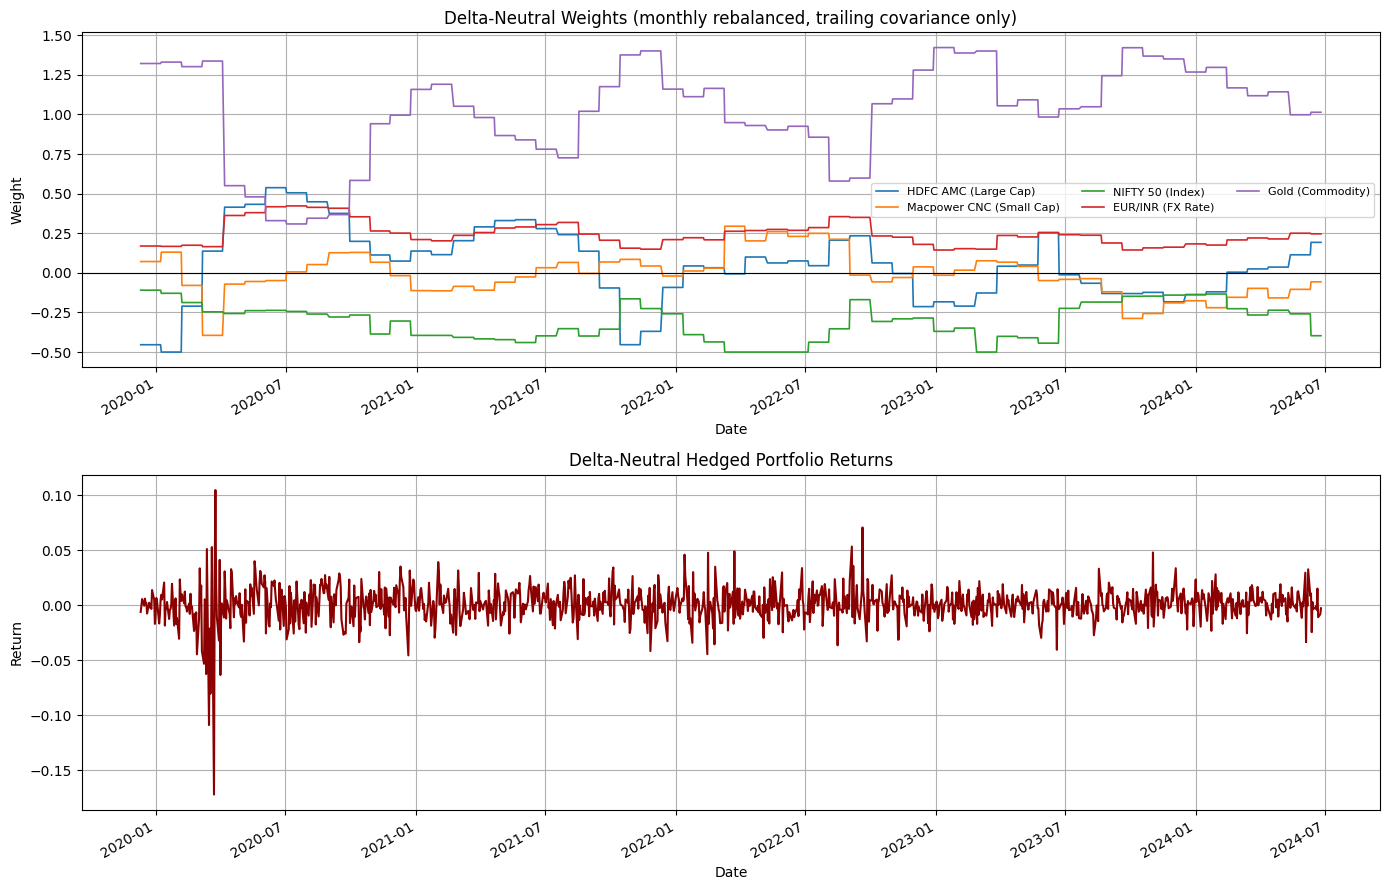

Summary Statistics of Delta-Neutral Hedged Portfolio:
Mean: 0.00109
Std Dev: 0.01563
Skewness: -1.29
Kurtosis: 17.26


,Equal-Weighted,Delta-Neutral
Mean,0.000803,0.001093
Std Dev,0.009958,0.015629
Skewness,-0.588305,-1.289508
Kurtosis,4.346866,17.259268


In [79]:
# Task - 7 Implementing Hedging Strategies - DELTA - NEUTRAL PORTFOLIO (corrected)
from scipy.optimize import minimize

# HDFC AMC, Macpower CNC, NIFTY 50, EUR/INR, Gold
delta_vector = np.array([1, 1, 1, -1, 0.5])
print("Delta exposures assumed:")
for name, d in zip(returns_df.columns, delta_vector):
    print(f"  {name:<28}: {d:+.2f}")

LOOKBACK = 126      # ~6 months of trailing daily data for the covariance estimate
REBAL_FREQ = 21     # rebalance monthly
BOUNDS = (-0.5, 1.5)  # allow modest shorting so delta=0 is not a corner solution

def solve_delta_neutral(cov, delta_vec, bounds=BOUNDS):
    n = len(delta_vec)
    x0 = np.array([1/n] * n)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.dot(w, delta_vec)},   # delta-neutral constraint
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}         # fully invested portfolio
    ]
    result = minimize(lambda w: w @ cov @ w, x0, method='SLSQP',
                       bounds=[bounds] * n, constraints=constraints,
                       options={'maxiter': 300, 'ftol': 1e-12})
    return result.x if result.success else None

# Rebalance monthly, using ONLY data strictly before the rebalance date
rebal_dates = returns_df.index[LOOKBACK::REBAL_FREQ]
weight_rows = {}
failures = 0
for dt in rebal_dates:
    hist = returns_df.loc[:dt].iloc[-LOOKBACK-1:-1]  # strictly past data, excludes dt itself
    if len(hist) < LOOKBACK:
        continue
    w = solve_delta_neutral(hist.cov().to_numpy(), delta_vector)
    if w is None:
        failures += 1
        continue
    weight_rows[dt] = w

rebalanced_weights_df = (
    pd.DataFrame(weight_rows, index=returns_df.columns).T
    .reindex(returns_df.index)
    .ffill()
    .dropna()
)
print(f"\nRebalances: {len(weight_rows)}   optimiser failures: {failures}")
print(f"Residual portfolio delta - max |delta . w| = "
      f"{np.abs(rebalanced_weights_df.to_numpy() @ delta_vector).max():.2e}")

# Apply weights to the NEXT day's returns only - nothing about day t+1 enters the day-t decision
aligned_returns = returns_df.loc[rebalanced_weights_df.index]
delta_neutral_returns = (rebalanced_weights_df.shift(1) * aligned_returns).sum(axis=1).iloc[1:]

# Plot rebalanced weights and the delta-neutral portfolio returns
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
rebalanced_weights_df.plot(ax=axes[0], lw=1.2)
axes[0].set_title("Delta-Neutral Weights (monthly rebalanced, trailing covariance only)")
axes[0].set_ylabel("Weight")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].grid(True)
axes[0].legend(fontsize=8, ncol=3)

delta_neutral_returns.plot(ax=axes[1], color="darkred")
axes[1].set_title("Delta-Neutral Hedged Portfolio Returns")
axes[1].set_ylabel("Return")
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Summary statistics
print("Summary Statistics of Delta-Neutral Hedged Portfolio:")
print(f"Mean: {delta_neutral_returns.mean():.5f}")
print(f"Std Dev: {delta_neutral_returns.std():.5f}")
print(f"Skewness: {skew(delta_neutral_returns):.2f}")
print(f"Kurtosis: {kurtosis(delta_neutral_returns):.2f}")

# Compare against the equal-weighted benchmark over the same window
benchmark_returns = portfolio_returns_df['Portfolio Returns'].loc[delta_neutral_returns.index]
comparison = pd.DataFrame({
    "Equal-Weighted": [benchmark_returns.mean(), benchmark_returns.std(),
                        skew(benchmark_returns), kurtosis(benchmark_returns)],
    "Delta-Neutral": [delta_neutral_returns.mean(), delta_neutral_returns.std(),
                       skew(delta_neutral_returns), kurtosis(delta_neutral_returns)],
}, index=["Mean", "Std Dev", "Skewness", "Kurtosis"])
comparison

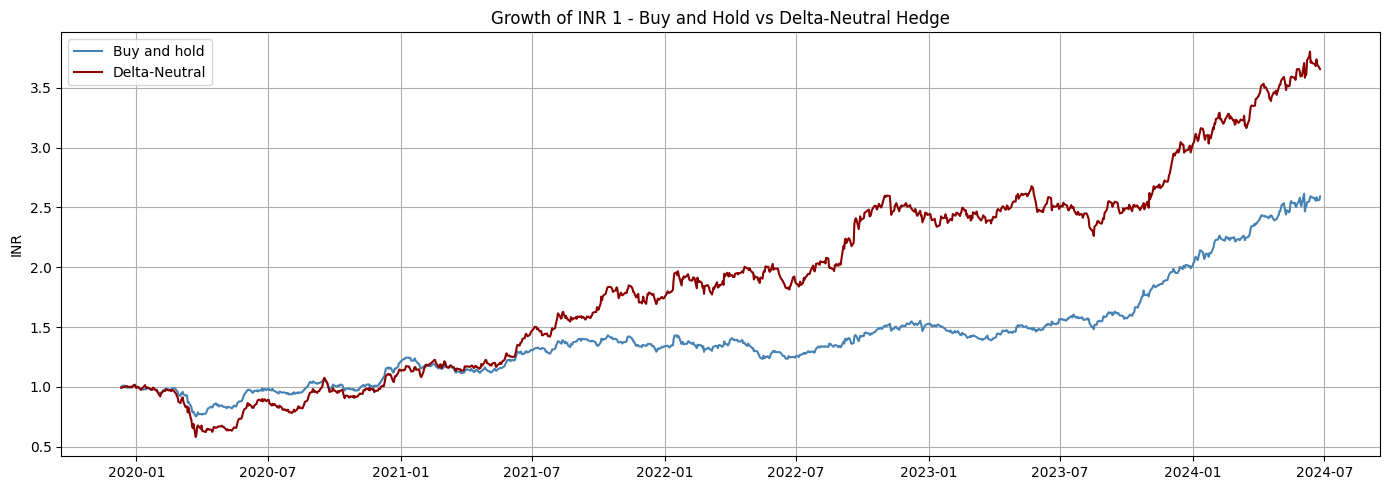

In [80]:
# Extra graph - growth of INR 1 invested, equal-weighted benchmark vs delta-neutral hedge
growth = np.exp(pd.concat([
    benchmark_returns.rename("Buy and hold"),
    delta_neutral_returns.rename("Delta-Neutral")
], axis=1).cumsum())

plt.figure(figsize=(14, 5))
plt.plot(growth.index, growth["Buy and hold"], label="Buy and hold", color="steelblue")
plt.plot(growth.index, growth["Delta-Neutral"], label="Delta-Neutral", color="darkred")
plt.title("Growth of INR 1 - Buy and Hold vs Delta-Neutral Hedge")
plt.ylabel("INR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()